# Notebook métricas de evaluación con RR Lyrae

Basado en Machine learning for physics and Astronomy, Viviana Acquaviva (2023)

En esta actividad trabajaremos con un problema de clasificación binaria: distinguir estrellas **RR Lyrae** de otras estrellas a partir de sus colores fotométricos.

### Los objetivos son
- entrenar un clasificador simple
- evaluar su rendimiento con distintas métricas
- interpretar una matriz de confusión
- comparar accuracy con precision, recall y F1
- discutir qué métrica conviene según el objetivo científico

### Contexto
Las RR Lyrae son estrellas variables pulsantes muy importantes en astronomía. En un catálogo grande, un clasificador puede ayudarnos a encontrar candidatas RR Lyrae, pero no basta con mirar solo el accuracy.


### Descripción de los datos
El set de datos que usará para esta tarea es sobre estrellas. Las características son colores en distintos filtros del [sistema ugriz de SDSS](https://www.physics.unlv.edu/~jeffery/astro/photometry/photometry_sdss.html), que son un indicador si la estrella emite luz más azul, verde, amarilla o roja. Queremos predecir a partir de estas características si la estrella es un tipo especial de estrella llamada variable RR Lyrae.

- Las características son los colores u-g, g-r, r-i, i-z
- El target es 0 (no RRLyrae) y 1 (RRLyrae)


In [1]:
import pandas as pd
import numpy as np

import sklearn.tree
from sklearn.tree import DecisionTreeClassifier #modelo
from sklearn.tree import plot_tree #visualizacion arbol
from sklearn.model_selection import train_test_split
from sklearn import metrics #métricas
from sklearn.model_selection import cross_val_predict, cross_val_score, cross_validate #validación cruzada
from sklearn.model_selection import KFold, StratifiedKFold #validación cruzada

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay #matriz de confusión


from scipy import stats

In [2]:
from io import StringIO
from IPython.display import Image
import pydotplus
from sklearn.tree import export_graphviz

In [3]:
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

font = {'size': 8}

matplotlib.rc('font', **font)
matplotlib.rc('xtick', labelsize=8)
matplotlib.rc('ytick', labelsize=8)
matplotlib.rcParams['figure.dpi'] = 300

pd.set_option('display.max_columns', 100) #Para poder visualizar todas las columnas del dataframe
pd.set_option('display.max_colwidth', 100)

## Primer paso: exploración de los datos

Siempre es importante hacer una análisis exploratorio del conjunto de datos que trabajaremos. Leemos el archivo como un dataframe y extraemos información básica

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
#cargamos los datos como arreglos numpy
features= np.loadtxt("/content/drive/MyDrive/RRLyrae_features_small.txt", delimiter=',')
targets= np.loadtxt("/content/drive/MyDrive/RRLyrae_labels_small.txt", delimiter=',')

In [6]:
columnas = ["u-g", "g-r", "r-i", "i-z"]
df = pd.DataFrame(features, columns=columnas)
df["RR_Lyrae"] = targets.astype(int)

df.head()

,u-g,g-r,r-i,i-z,RR_Lyrae
0,0.311,0.714,0.093,0.204,0
1,0.332,0.965,0.122,0.032,0
2,0.394,1.019,0.147,0.096,0
3,0.285,0.865,0.120,0.039,0
4,0.386,0.977,0.181,0.080,0


In [7]:
#calcular el desbalance de los datos
df["RR_Lyrae"].value_counts()



,count
RR_Lyrae,
0,2000
1,483


### Preguntas
1. ¿Este es un problema de clasificación o regresión?
2. ¿Es un problema binario o multiclase?
3. ¿Qué representa la variable objetivo?
4. ¿Las clases están balanceadas o desbalanceadas?
5. ¿Por qué esto podría ser importante al elegir una métrica de evaluación?

1. Es un problema de clasificación.
2. Binario.
3. La naturaleza física de la estrella según su color.
4. Están desbalanceadas.
5. Por que no podemos confiar plenamente en el accuracy cuando las clases están desbalanceadas.

#### Haga una visualización de sólo dos columnas para revisar los colores de las RR Lyrae y las no RRLyrae

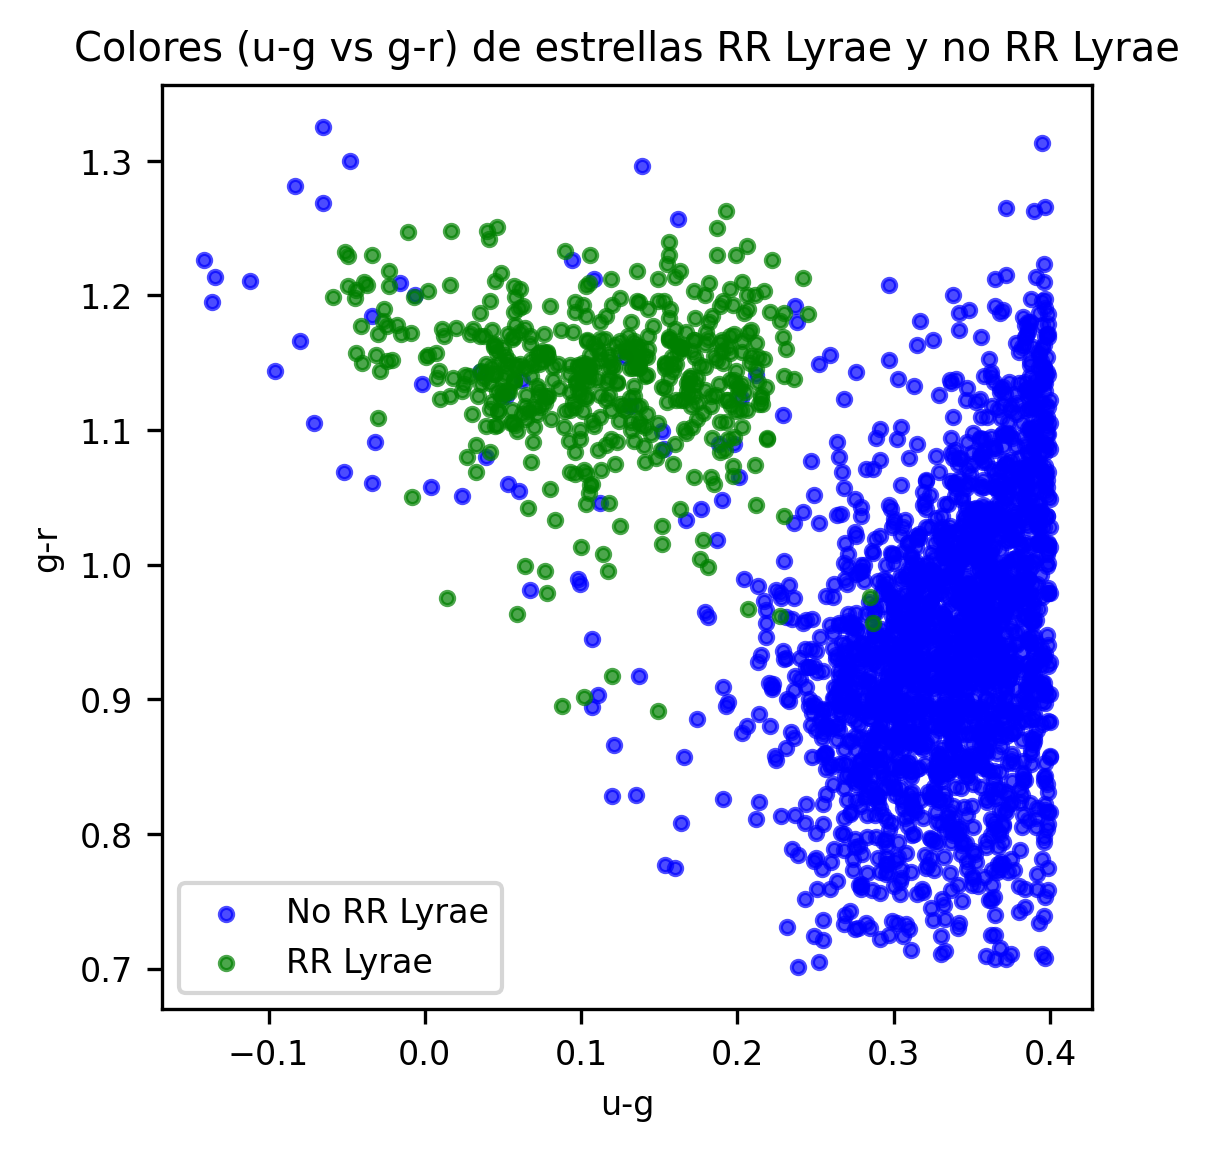

In [8]:
plt.figure(figsize=(4,4))

plt.scatter(df[df['RR_Lyrae'] == 0]['u-g'], df[df['RR_Lyrae'] == 0]['g-r'], color='blue', s=10, alpha=0.7, label='No RR Lyrae')
plt.scatter(df[df['RR_Lyrae'] == 1]['u-g'], df[df['RR_Lyrae'] == 1]['g-r'], color='green', s=10, alpha=0.7, label='RR Lyrae')

plt.xlabel('u-g')
plt.ylabel('g-r')
plt.title('Colores (u-g vs g-r) de estrellas RR Lyrae y no RR Lyrae')
plt.legend()

plt.show()

### Pregunta
1. ¿Se observan regiones donde las clases parecen separarse?
2. A simple vista, ¿esperarías que un árbol de decisión funcione razonablemente bien?

1. Sí, se ve que hay una región poblada casi completamente por No RR Lyrae en la parte inferior del gráfico
2. Probablemente si

#### Separe los datos en entrenamiento y prueba

In [9]:
X = df[["u-g", "g-r", "r-i", "i-z"]]
y = df["RR_Lyrae"]

In [10]:
#complete la celda
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

### Antes de continuar

Las clases en este problema no están perfectamente balanceadas.

Piense en la forma en que podríamos separar los datos en entrenamiento y prueba, y responda:

1. ¿Qué problema podría ocurrir si hacemos la partición de manera completamente aleatoria, sin preocuparnos por la proporción de clases?
2. ¿Por qué eso podría afectar la evaluación del modelo?
3. ¿Qué tipo de precaución cree que sería razonable tomar al construir los conjuntos de entrenamiento y prueba en este caso?

1. Si las clases están desbalanceadas y realizamos una partición completamente aleatoria, es posible que el conjunto de entrenamiento o el de prueba (o ambos) termine con muy pocos o incluso ningún ejemplo de la clase minoritaria.
2.  Si el conjunto de prueba no contiene suficientes ejemplos de la clase minoritaria, la evaluación del modelo será poco fiable para esa clase. No podremos saber qué tan bien predice el modelo la clase minoritaria si no hay ejemplos para evaluar.
3. La precaución más razonable es utilizar la estratificación. La estratificación asegura que la proporción de cada clase se mantenga en los conjuntos de entrenamiento y prueba, tal como en el conjunto de datos original.

#### Ahora entrenaremos un árbol de decisión (modelo base)

In [11]:
model_tree = DecisionTreeClassifier(random_state=42)
model_tree.fit(X_train, y_train)

#entrene el modelo y genere las predicciones





DecisionTreeClassifier(random_state=42)

In [12]:
y_pred = model_tree.predict(X_test)

#### Visualicemos el árbol

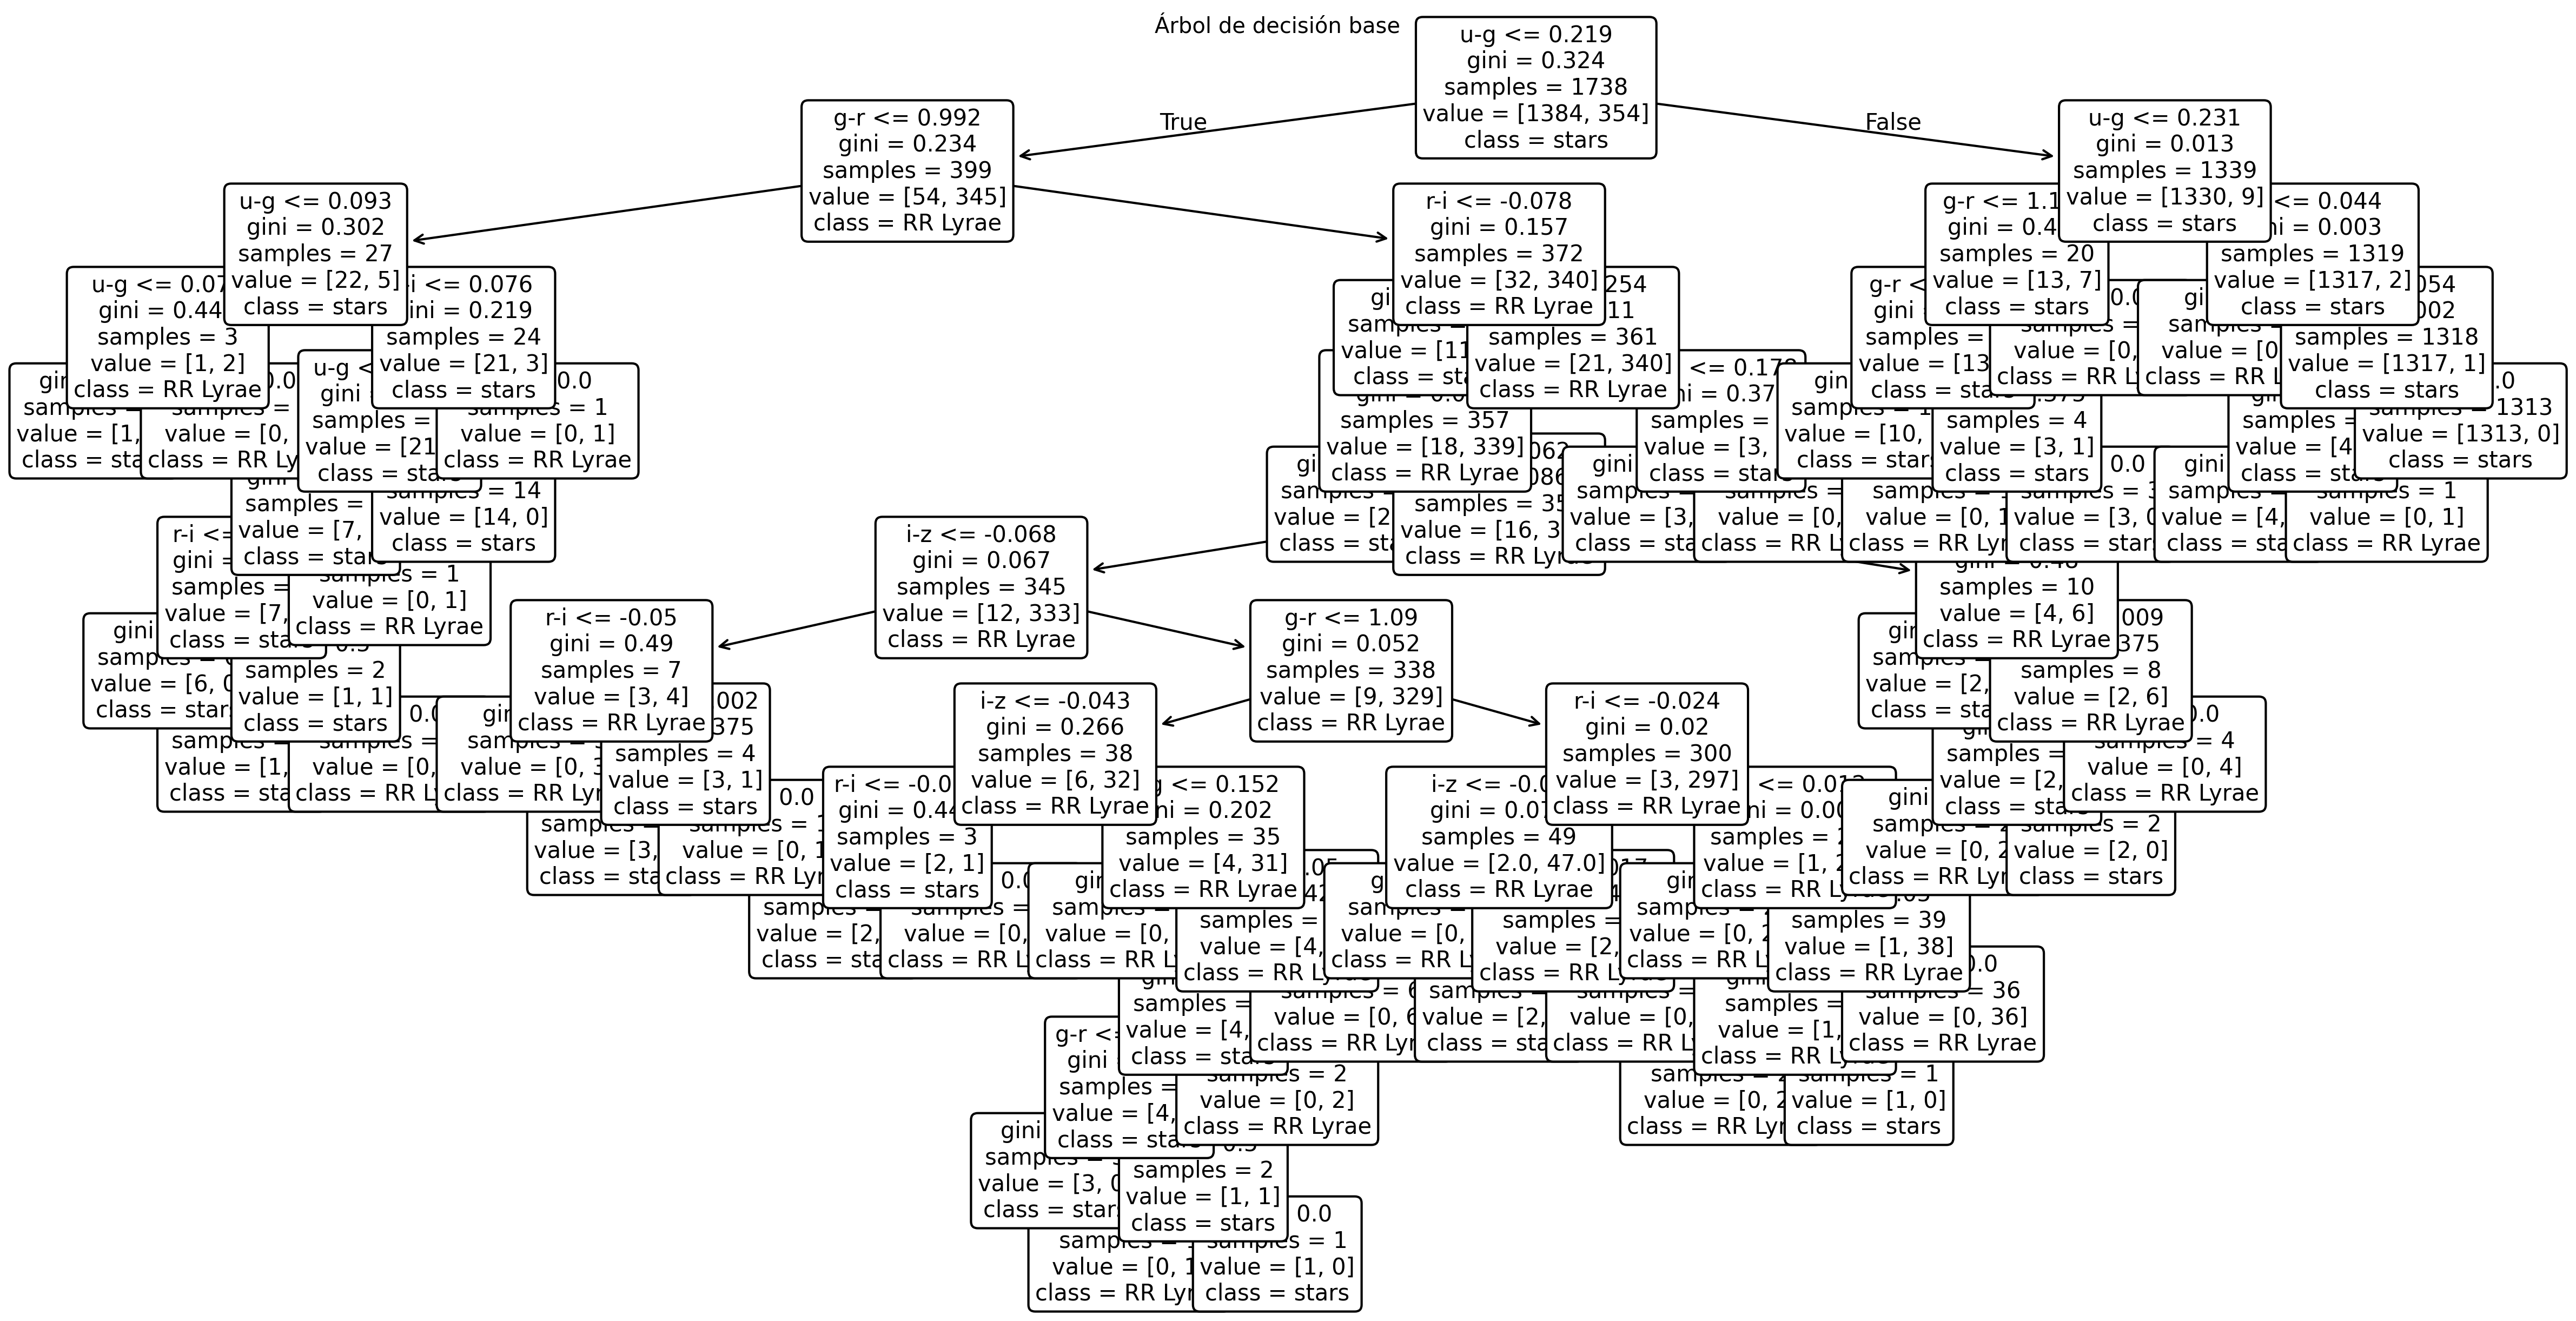

In [13]:
plt.figure(figsize=(20,10))

plot_tree(
    model_tree,
    feature_names=X.columns,
    class_names=["stars", "RR Lyrae"],
    filled=False,
    rounded=True,
    #max_depth=3,
    fontsize=10
)

plt.title("Árbol de decisión base")
plt.show()

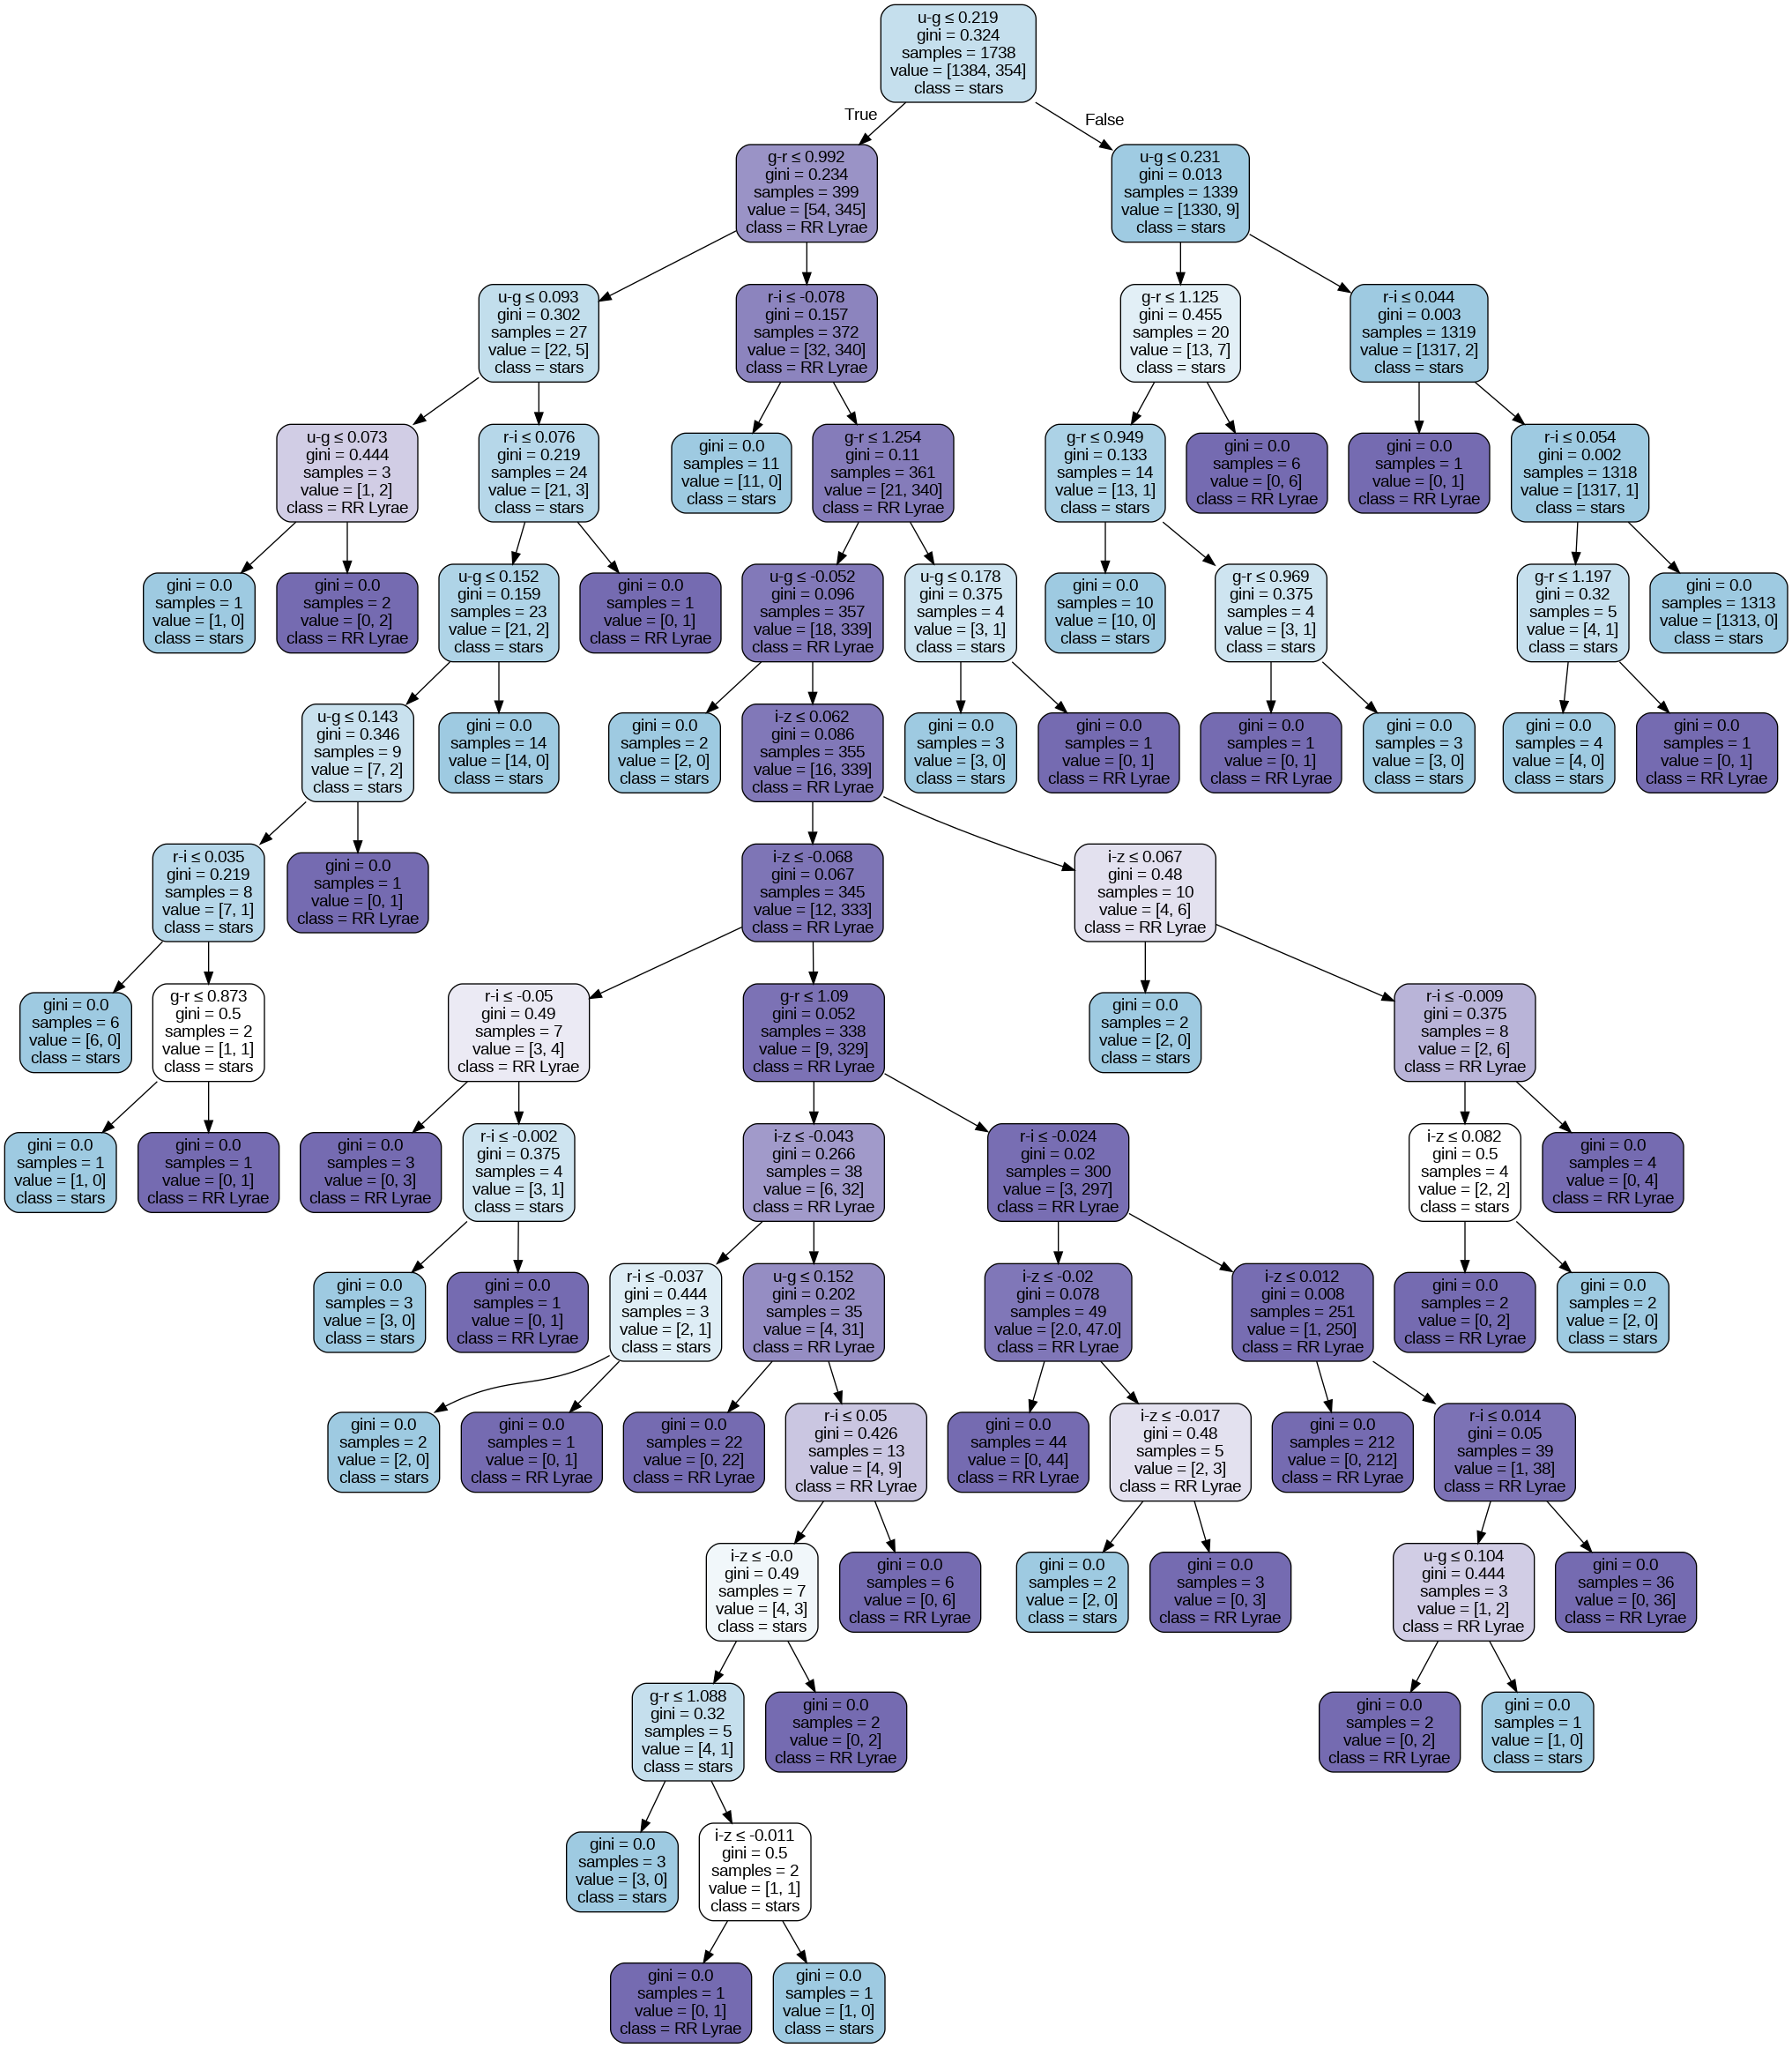

In [14]:
# Recordatorio: Las características siempre se permutan aleatoriamente en cada división.
# Por lo tanto, la mejor división encontrada puede variar, incluso con los mismos datos
# de entrenamiento y max_features=n_features, si la mejora del criterio es idéntica
# para varias divisiones enumeradas durante la búsqueda de la mejor división.
# Para obtener un comportamiento determinista durante el ajuste, random_state debe estar fijo.

dot_data = StringIO()

export_graphviz(
    model_tree,
    out_file=dot_data,
    feature_names=['u-g', 'g-r', 'r-i', 'i-z'],
    class_names=['stars', 'RR Lyrae'],
    filled=True,
    rounded=True,
    special_characters=True
)

graph = pydotplus.graph_from_dot_data(dot_data.getvalue().replace("\n", ""))
nodes = graph.get_node_list()

for node in nodes:
    if node.get_label() and 'value = [' in node.get_label():

        values = [float(ii) for ii in node.get_label().split('value = [')[1].split(']')[0].split(',')]
        values = [int(255 * v / sum(values)) for v in values]

        if values[0] > values[1]:
            alpha = int(values[0] - values[1])
            alpha = '{:02x}'.format(alpha)
            color = '#9ecae1' + str(alpha)   # turquesa
        else:
            alpha = int(values[1] - values[0])
            alpha = '{:02x}'.format(alpha)
            color = '#756bb1' + str(alpha)   # magenta

        node.set_fillcolor(color)

Image(graph.create_png())

In [15]:
#calcular el numero de niveles que tiene el árbol
model_tree.get_depth()


14

### Preguntas

Observe la estructura del árbol y responda brevemente:

1. ¿El árbol parece muy simple o bastante complejo? Justifique a partir del número de niveles o divisiones.
2. ¿Qué desventaja podría tener un árbol demasiado grande en un problema como este?

1. EL árbol se ve demasiado complejo, tiene 14 niveles
2. Un árbol demasiado grande implica que tiene un sobreajuste.

#### Miremos las métricas accuracy para set de entrenamiento y prueba

In [16]:
print(metrics.accuracy_score(y_train, model_tree.predict(X_train))) #train score

print(metrics.accuracy_score(y_test, model_tree.predict(X_test))) #test score

1.0
0.9651006711409396


#### Otras métricas

In [17]:
print("Precision:", metrics.precision_score(y_test, y_pred))
print("Recall   :", metrics.recall_score(y_test, y_pred))
print("F1-score :", metrics.f1_score(y_test, y_pred))

Precision: 0.8759124087591241
Recall   : 0.9302325581395349
F1-score : 0.9022556390977443


In [18]:
cm = confusion_matrix(y_test, y_pred)
cm

array([[599,  17],
       [  9, 120]])

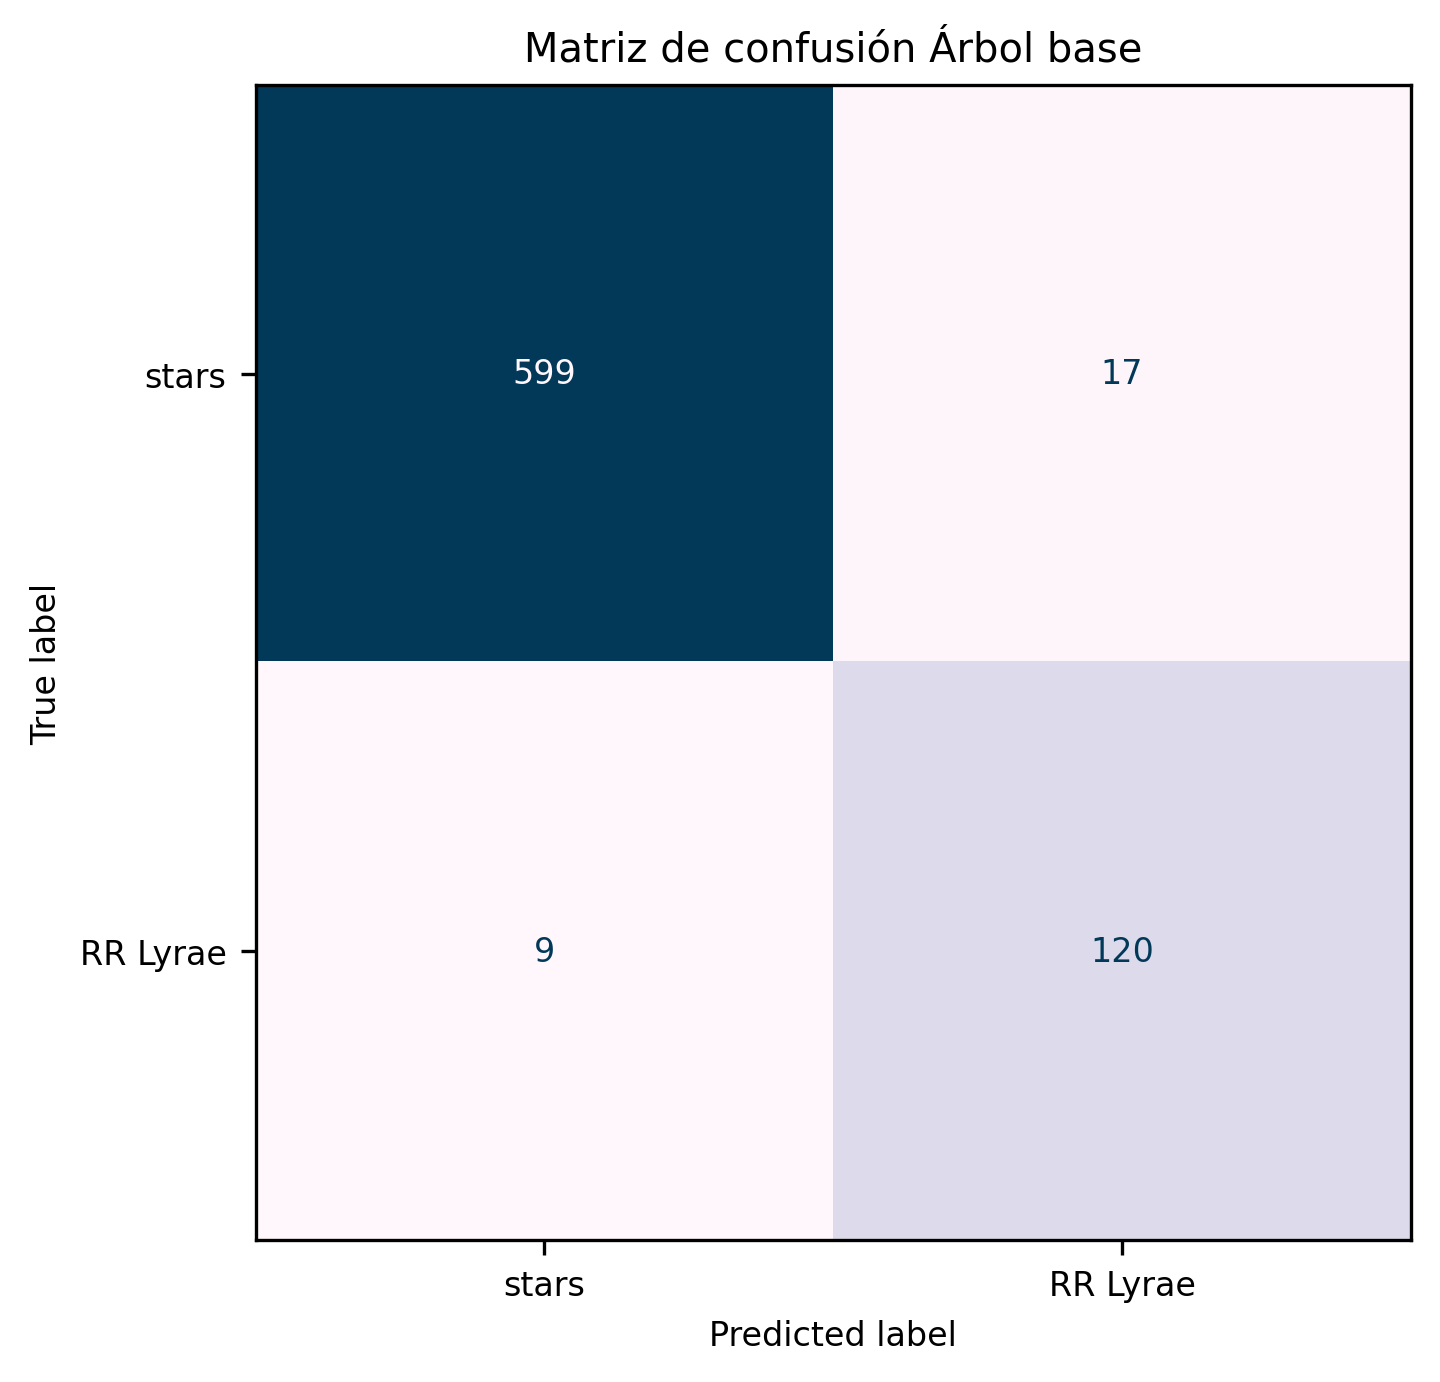

In [19]:
fig, ax = plt.subplots(figsize=(5,5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["stars", "RR Lyrae"])
disp.plot(cmap="PuBu", ax=ax, colorbar=False)

plt.title("Matriz de confusión Árbol base")
plt.show()

#### A partir de la matriz de confusión obtenida:
1.  Identifique los valores de:
   - verdaderos positivos (TP)
   - verdaderos negativos (TN)
   - falsos positivos (FP)
   - falsos negativos (FN)
2. Calcule las métricas "a mano"



TP: 120

TN: 599

FP: 17

FN: 9

In [20]:
Precision = 120/(120+17)
print(Precision)

Recall = 120/(120+9)
print(Recall)

0.8759124087591241
0.9302325581395349


### Preguntas
1. Explique con sus palabras qué significa, en este problema:
   - un falso positivo
   - un falso negativo

2. Si el objetivo científico fuera encontrar la mayor cantidad posible de RR Lyrae, ¿qué tipo de error preocuparía más?

3. Si el objetivo fuera construir una muestra final más limpia, ¿qué tipo de error preocuparía más?

1. Un falso positivo significa que nuestro modelo predijo que una estrella es una RR Lyrae, pero en realidad no lo es. Un falso negativo significa que nuestro modelo predijo que una estrella NO es una RR Lyrae, pero en realidad SÍ lo es.

2. En este caso, nos preocuparía más un Falso Negativo. Si el objetivo es no perder ninguna RR Lyrae (es decir, encontrar todas las que existen), un falso negativo significaría que estamos dejando pasar estrellas RR Lyrae reales que podrían ser importantes para nuestro estudio. Preferiríamos tener algunos falsos positivos (examinar algunas estrellas que no son RR Lyrae) antes que perder una RR Lyrae verdadera.

3. Entonces nos preocuparía más un Falso Positivo. Un falso positivo significaría que nuestra muestra 'limpia' contiene estrellas que no son RR Lyrae, lo que la 'contaminaría'. En este escenario, preferiríamos ser más estrictos y solo incluir estrellas de las que estamos casi 100% seguros de que son RR Lyrae, aunque eso signifique perder algunas verdaderas RR Lyrae (falsos negativos) en el proceso.

#### Todo parece funcionar bien, pero sólo hicimos un split. Necesitamos que el resultados sea robusto. Para esto, implementaremos Cross-validation usando [k-fold](https://scikit--learn-org.translate.goog/stable/modules/generated/sklearn.model_selection.KFold.html?_x_tr_sl=en&_x_tr_tl=es&_x_tr_hl=es&_x_tr_pto=tc)

In [21]:
# Esta es la versión estándar. Importante: no baraja los datos, por lo que si tus
# ejemplos positivos están todos al principio o al final, podría llevar a resultados
# desastrosos.

cv1 = KFold(n_splits = 5)

#Esta es la versión 2: se ha añadido el barajado (¡recomendado!)

cv2 = KFold(shuffle = True, n_splits = 5, random_state=5)

# LA ESTRATIFICACIÓN asegura que las distribuciones de clases en cada división se
# asemejen a las del conjunto de datos completo.

cv3 = StratifiedKFold(shuffle = True, n_splits = 5, random_state=5)


### Efecto de la estratificación: veamos el conteo de clases en cada conjunto de divisiones.

In [22]:
cv1.split(X, y)

<generator object _BaseKFold.split at 0x7c882e4c7ef0>

In [23]:
for train, test in cv1.split(X, y):
...     print('train -  {}   |   test -  {}'.format(
...         np.bincount(y.loc[train]), np.bincount(y.loc[test])))

train -  [1503  483]   |   test -  [497]
train -  [1503  483]   |   test -  [497]
train -  [1503  483]   |   test -  [497]
train -  [1504  483]   |   test -  [496]
train -  [1987]   |   test -  [ 13 483]


In [24]:
for train, test in cv2.split(X, y):
...     print('train -  {}   |   test -  {}'.format(
...         np.bincount(y.loc[train]), np.bincount(y.loc[test])))

train -  [1600  386]   |   test -  [400  97]
train -  [1610  376]   |   test -  [390 107]
train -  [1587  399]   |   test -  [413  84]
train -  [1599  388]   |   test -  [401  95]
train -  [1604  383]   |   test -  [396 100]


In [25]:
for train, test in cv3.split(X, y):
...     print('train -  {}   |   test -  {}'.format(
...         np.bincount(y.loc[train]), np.bincount(y.loc[test])))

train -  [1600  386]   |   test -  [400  97]
train -  [1600  386]   |   test -  [400  97]
train -  [1600  386]   |   test -  [400  97]
train -  [1600  387]   |   test -  [400  96]
train -  [1600  387]   |   test -  [400  96]


### La función [`cross_validate`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_validate.html#sklearn.model_selection.cross_validate) proporciona los puntajes (especificados por el parámetro de evaluación elegido), en forma de diccionario.

In [26]:
scores1 = cross_validate(model_tree, X, y, cv = cv1, scoring = 'accuracy')

scores2 = cross_validate(model_tree, X, y, cv = cv2, scoring = 'accuracy')

scores3 = cross_validate(model_tree, X, y, cv = cv3, scoring = 'accuracy')

In [27]:
scores3

{'fit_time': array([0.00695634, 0.0061357 , 0.0071013 , 0.00725865, 0.00671244]),
 'score_time': array([0.00219631, 0.00206494, 0.00232387, 0.00220966, 0.0026207 ]),
 'test_score': array([0.9778672 , 0.96981891, 0.96780684, 0.97379032, 0.96572581])}

Solo nos interesa el 'test_score'

#### Calculamos el promedio y $\sigma$

In [28]:
print("{:.3f}".format(scores1['test_score'].mean()), "{:.3f}".format(scores1['test_score'].std()))

0.786 0.380


In [29]:
print("{:.3f}".format(scores2['test_score'].mean()), "{:.3f}".format(scores2['test_score'].std()))

0.965 0.012


In [30]:
print("{:.3f}".format(scores3['test_score'].mean()), "{:.3f}".format(scores3['test_score'].std()))

0.971 0.004


La validación cruzada sin barajar (`cv1`) produce un resultado muy inestable, con una desviación estándar extremadamente alta. Esto ocurre porque los datos están ordenados por clase, de modo que algunos folds no representan bien el problema completo.

Al activar el barajado (`cv2`), el rendimiento mejora drásticamente y la dispersión disminuye. Sin embargo, el método que resulta más apropiado para este problema es `StratifiedKFold` (`cv3`), ya que además de mezclar los datos, conserva aproximadamente la proporción de clases en cada fold.

En problemas de clasificación desbalanceada, esta última estrategia suele ser la más recomendable.

In [31]:
scores1 = cross_validate(model_tree, X,y, cv = cv1, scoring = 'recall')

scores2 = cross_validate(model_tree, X,y, cv = cv2, scoring = 'recall')

scores3 = cross_validate(model_tree, X,y, cv = cv3, scoring = 'recall')

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricW

In [32]:
print("{:.3f}".format(scores1['test_score'].mean()), "{:.3f}".format(scores1['test_score'].std()))
print("{:.3f}".format(scores2['test_score'].mean()), "{:.3f}".format(scores2['test_score'].std()))
print("{:.3f}".format(scores3['test_score'].mean()), "{:.3f}".format(scores3['test_score'].std()))

nan nan
0.914 0.033
0.932 0.014


### ¿Por qué aparece este warning?

En algunos folds generados por `KFold` sin barajado, el conjunto de prueba contiene solo ejemplos de una clase. En ese caso, el recall de la clase positiva (RR Lyrae) no puede calcularse, porque no hay positivos reales en ese fold.

Esto muestra que una estrategia de partición inadecuada puede hacer que la evaluación sea inestable, engañosa o incluso inválida.

#### También extraeremos los train scores, que nos servirán cuando estemos diagnosticando el modelo a través de bias vs variance.¶

In [33]:
scores1 = cross_validate(model_tree, X,y, cv = cv1, scoring = 'recall', \
                         return_train_score = True)

scores2 = cross_validate(model_tree, X,y, cv = cv2, scoring = 'recall', \
                         return_train_score = True)

scores3 = cross_validate(model_tree, X,y, cv = cv3, scoring = 'recall',
                         return_train_score = True)

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricW

In [34]:
print("{:.3f}".format(scores1['test_score'].mean()), "{:.3f}".format(scores1['train_score'].mean()))
print("{:.3f}".format(scores2['test_score'].mean()), "{:.3f}".format(scores2['train_score'].mean()))
print("{:.3f}".format(scores3['test_score'].mean()), "{:.3f}".format(scores3['train_score'].mean()))

nan nan
0.914 1.000
0.932 1.000


### La función  `cross_validate` es útil para calcular el puntaje, pero no produce etiquetas predichas.

#### Estas pueden obtenerse utilizando la función [`cross_val_predict`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_val_predict.html), que guarda las predicciones para cada uno de los k-folds de prueba y las compila juntas.


In [35]:
model1 = model_tree

y_cv3 = cross_val_predict(model1, X,y, cv = cv3)
# Estas son las predicciones,
# y son independientes del parámetro de evaluación

In [36]:
metrics.confusion_matrix(targets,y_cv3)

array([[1961,   39],
       [  33,  450]])

### Sin embargo, las cosas pueden cambiar si uso un esquema de validación cruzada diferente:

In [37]:
model2 = model_tree

y_cv2 = cross_val_predict(model2, X,y, cv = cv2)

In [38]:
np.sum(y_cv3-y_cv2)

np.int64(4)

In [39]:
np.sum(y_cv2)

np.int64(485)

In [40]:
np.sum(y_cv3 != y_cv2) #comparando las predicciones

np.int64(52)

In [41]:
metrics.confusion_matrix(targets,y_cv2)

array([[1956,   44],
       [  42,  441]])

In [42]:
metrics.confusion_matrix(targets,y_cv3)

array([[1961,   39],
       [  33,  450]])

In [43]:
from sklearn.model_selection import learning_curve

def plot_learning_curve(estimator, title, X, y, ylim=None, cv=5,
                        n_jobs=-1, train_sizes=np.linspace(0.2, 1.0, 5), scoring = 'accuracy'):
    """
    Generate a simple plot of the test and training learning curve.

    Parameters
    ----------
    estimator : object type that implements the "fit" and "predict" methods
        An object of that type which is cloned for each validation.

    title : string
        Title for the chart.

    X : array-like, shape (n_samples, n_features)
        Training vector, where n_samples is the number of samples and
        n_features is the number of features.

    y : array-like, shape (n_samples) or (n_samples, n_features), optional
        Target relative to X for classification or regression;
        None for unsupervised learning.

    ylim : tuple, shape (ymin, ymax), optional
        Defines minimum and maximum yvalues plotted.

    cv : int, cross-validation generator or an iterable, optional
        Determines the cross-validation splitting strategy.
        Possible inputs for cv are:
          - None, to use the default 3-fold cross-validation,
          - integer, to specify the number of folds.
          - :term:`CV splitter`,
          - An iterable yielding (train, test) splits as arrays of indices.

        For integer/None inputs, if ``y`` is binary or multiclass,
        :class:`StratifiedKFold` used. If the estimator is not a classifier
        or if ``y`` is neither binary nor multiclass, :class:`KFold` is used.

        Refer :ref:`User Guide <cross_validation>` for the various
        cross-validators that can be used here.

    n_jobs : int or None, optional (default=None)
        Number of jobs to run in parallel.
        ``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.
        ``-1`` means using all processors. See :term:`Glossary <n_jobs>`
        for more details.

    train_sizes : array-like, shape (n_ticks,), dtype float or int
        Relative or absolute numbers of training examples that will be used to
        generate the learning curve. If the dtype is float, it is regarded as a
        fraction of the maximum size of the training set (that is determined
        by the selected validation method), i.e. it has to be within (0, 1].
        Otherwise it is interpreted as absolute sizes of the training sets.
        Note that for classification the number of samples usually have to
        be big enough to contain at least one sample from each class.
        (default: np.linspace(0.1, 1.0, 5))
    """
    plt.figure(figsize=(10,6))
    plt.title(title)
    if ylim is not None:
        plt.ylim(*ylim)
    plt.xlabel("Training examples")
    plt.ylabel(str(scoring))

    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=cv, n_jobs=n_jobs, train_sizes=train_sizes, scoring = scoring, shuffle=True, random_state=42)
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)
    plt.grid()

    plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1,
                     color="r")
    plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha=0.1, color="g")
    plt.plot(train_sizes, train_scores_mean, 'o-', color="r",
             label="Training score")
    plt.plot(train_sizes, test_scores_mean, 'o-', color="g",
             label="Test score from cross-validation")

    plt.legend(loc="best")
    return plt

In [44]:
model = model_tree

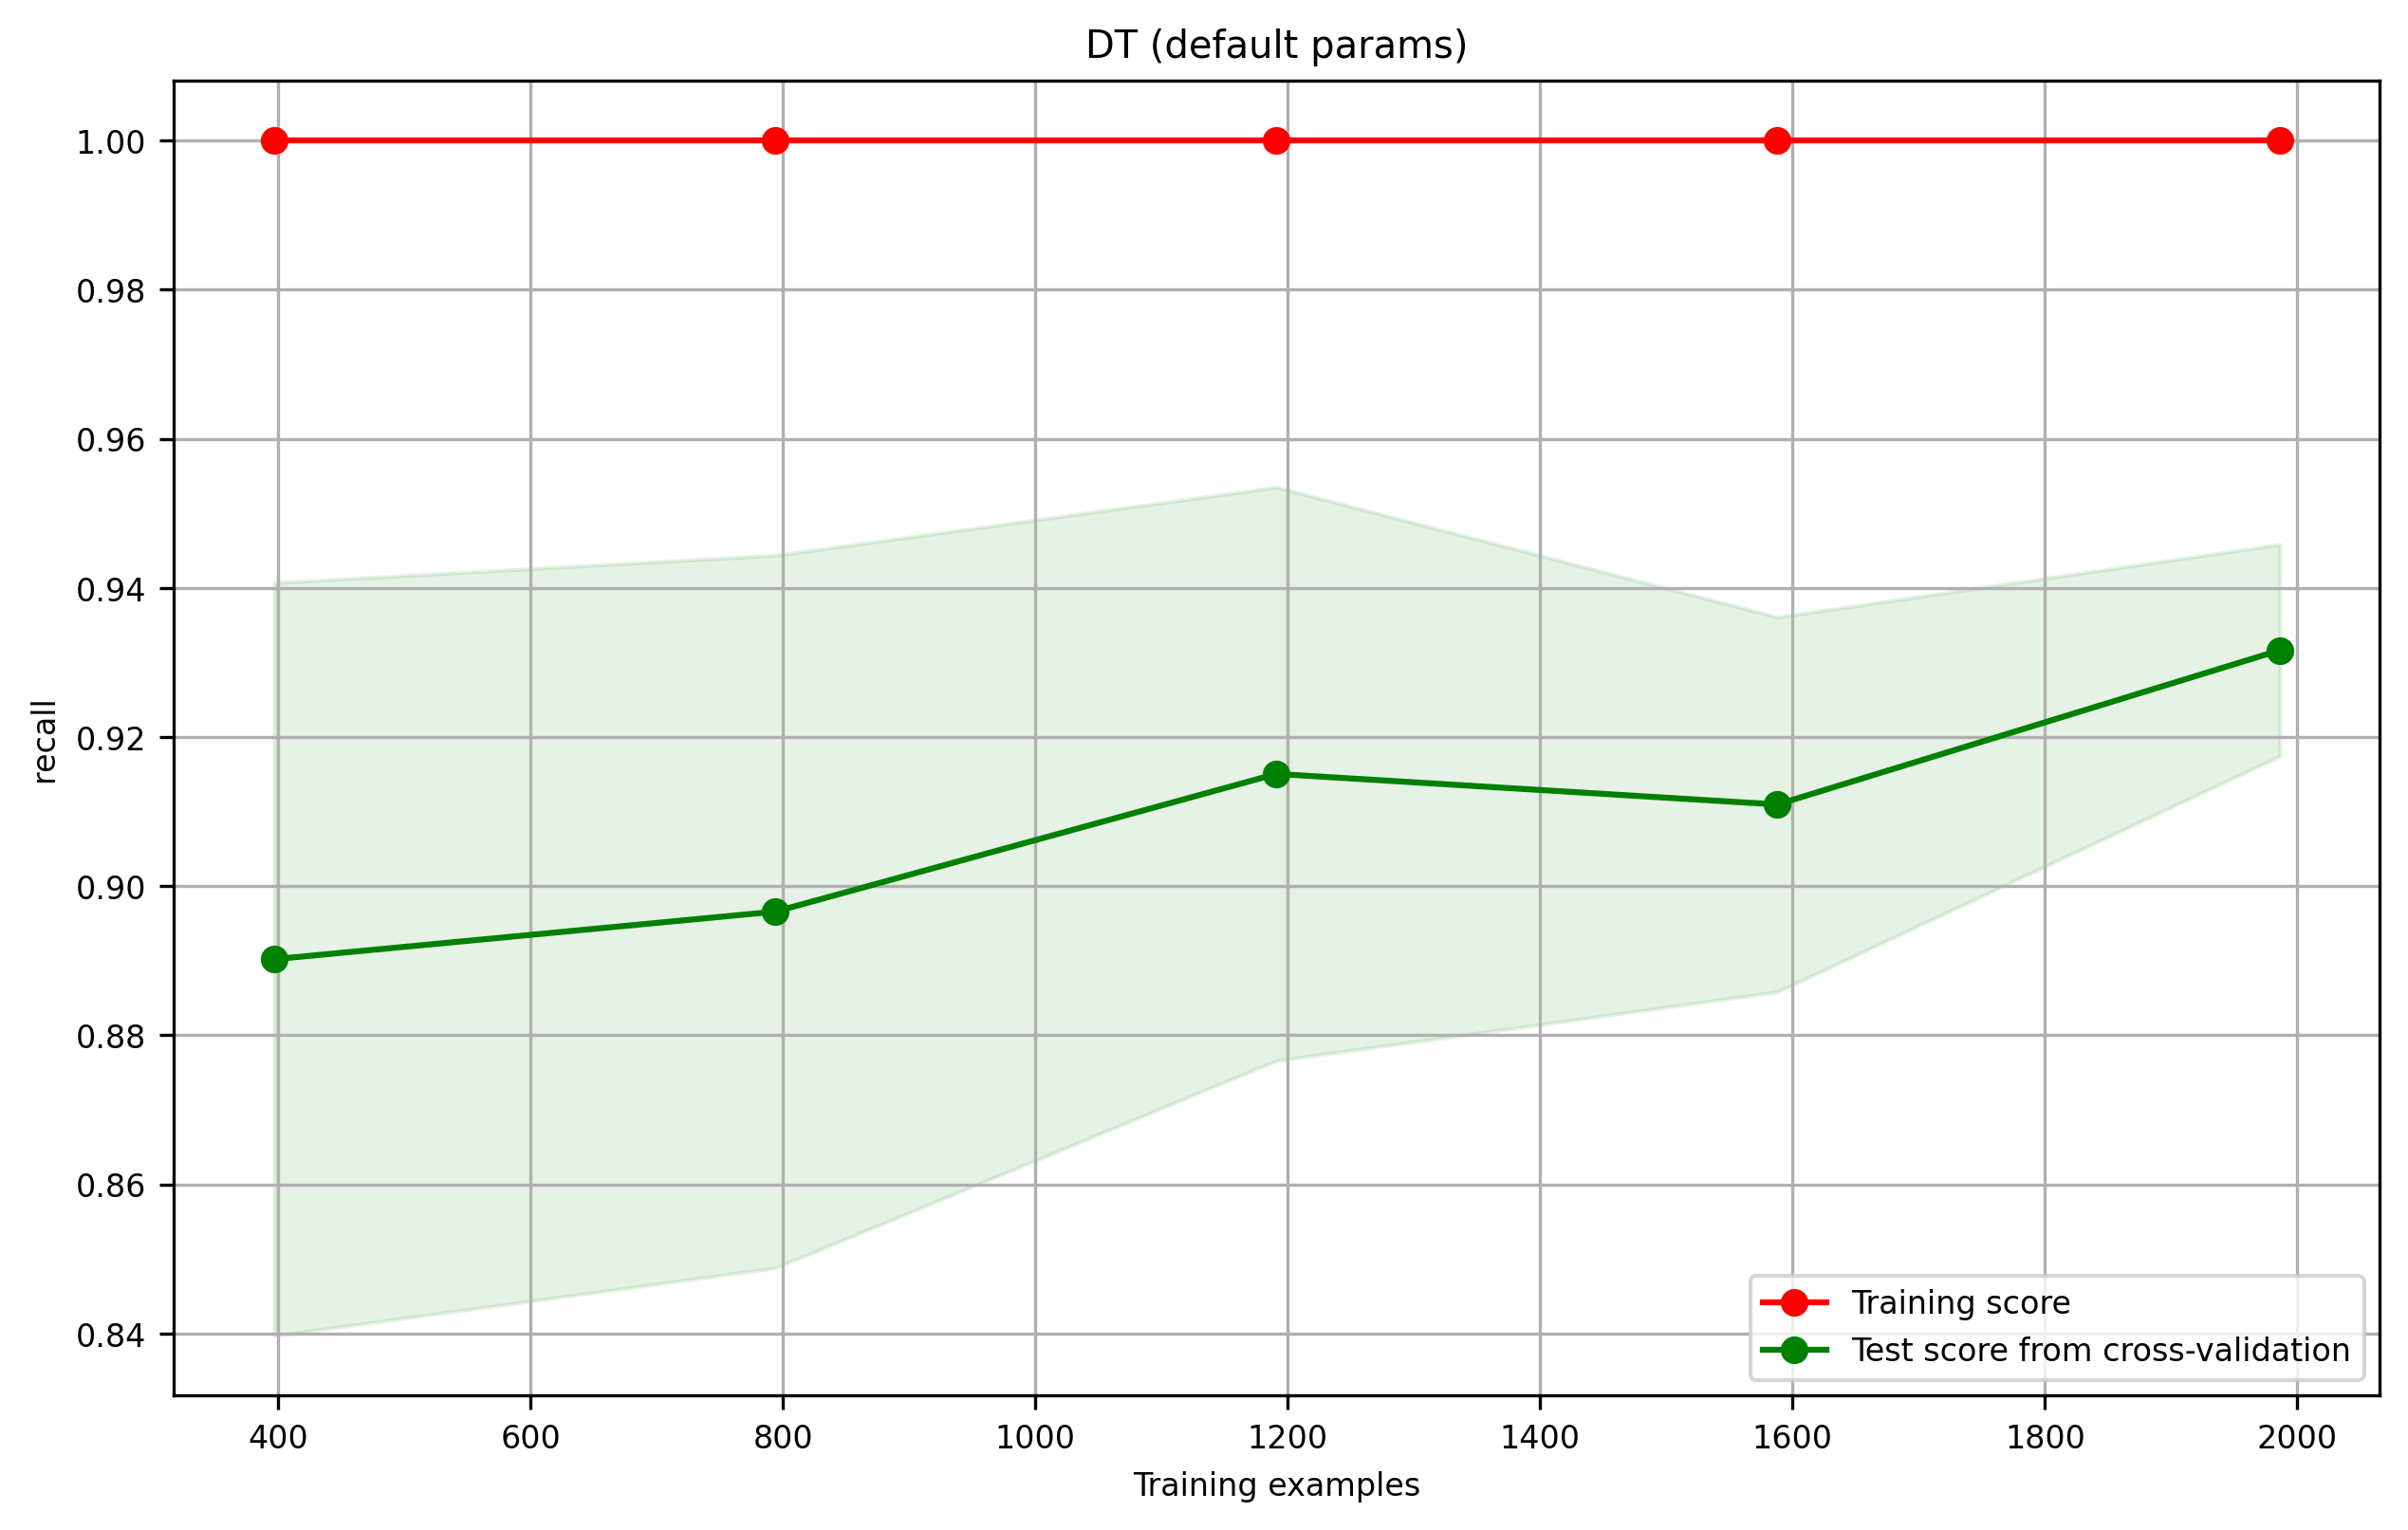

In [45]:
plot_learning_curve(model, 'DT (default params)', X, y,  cv = cv3, scoring = 'recall');

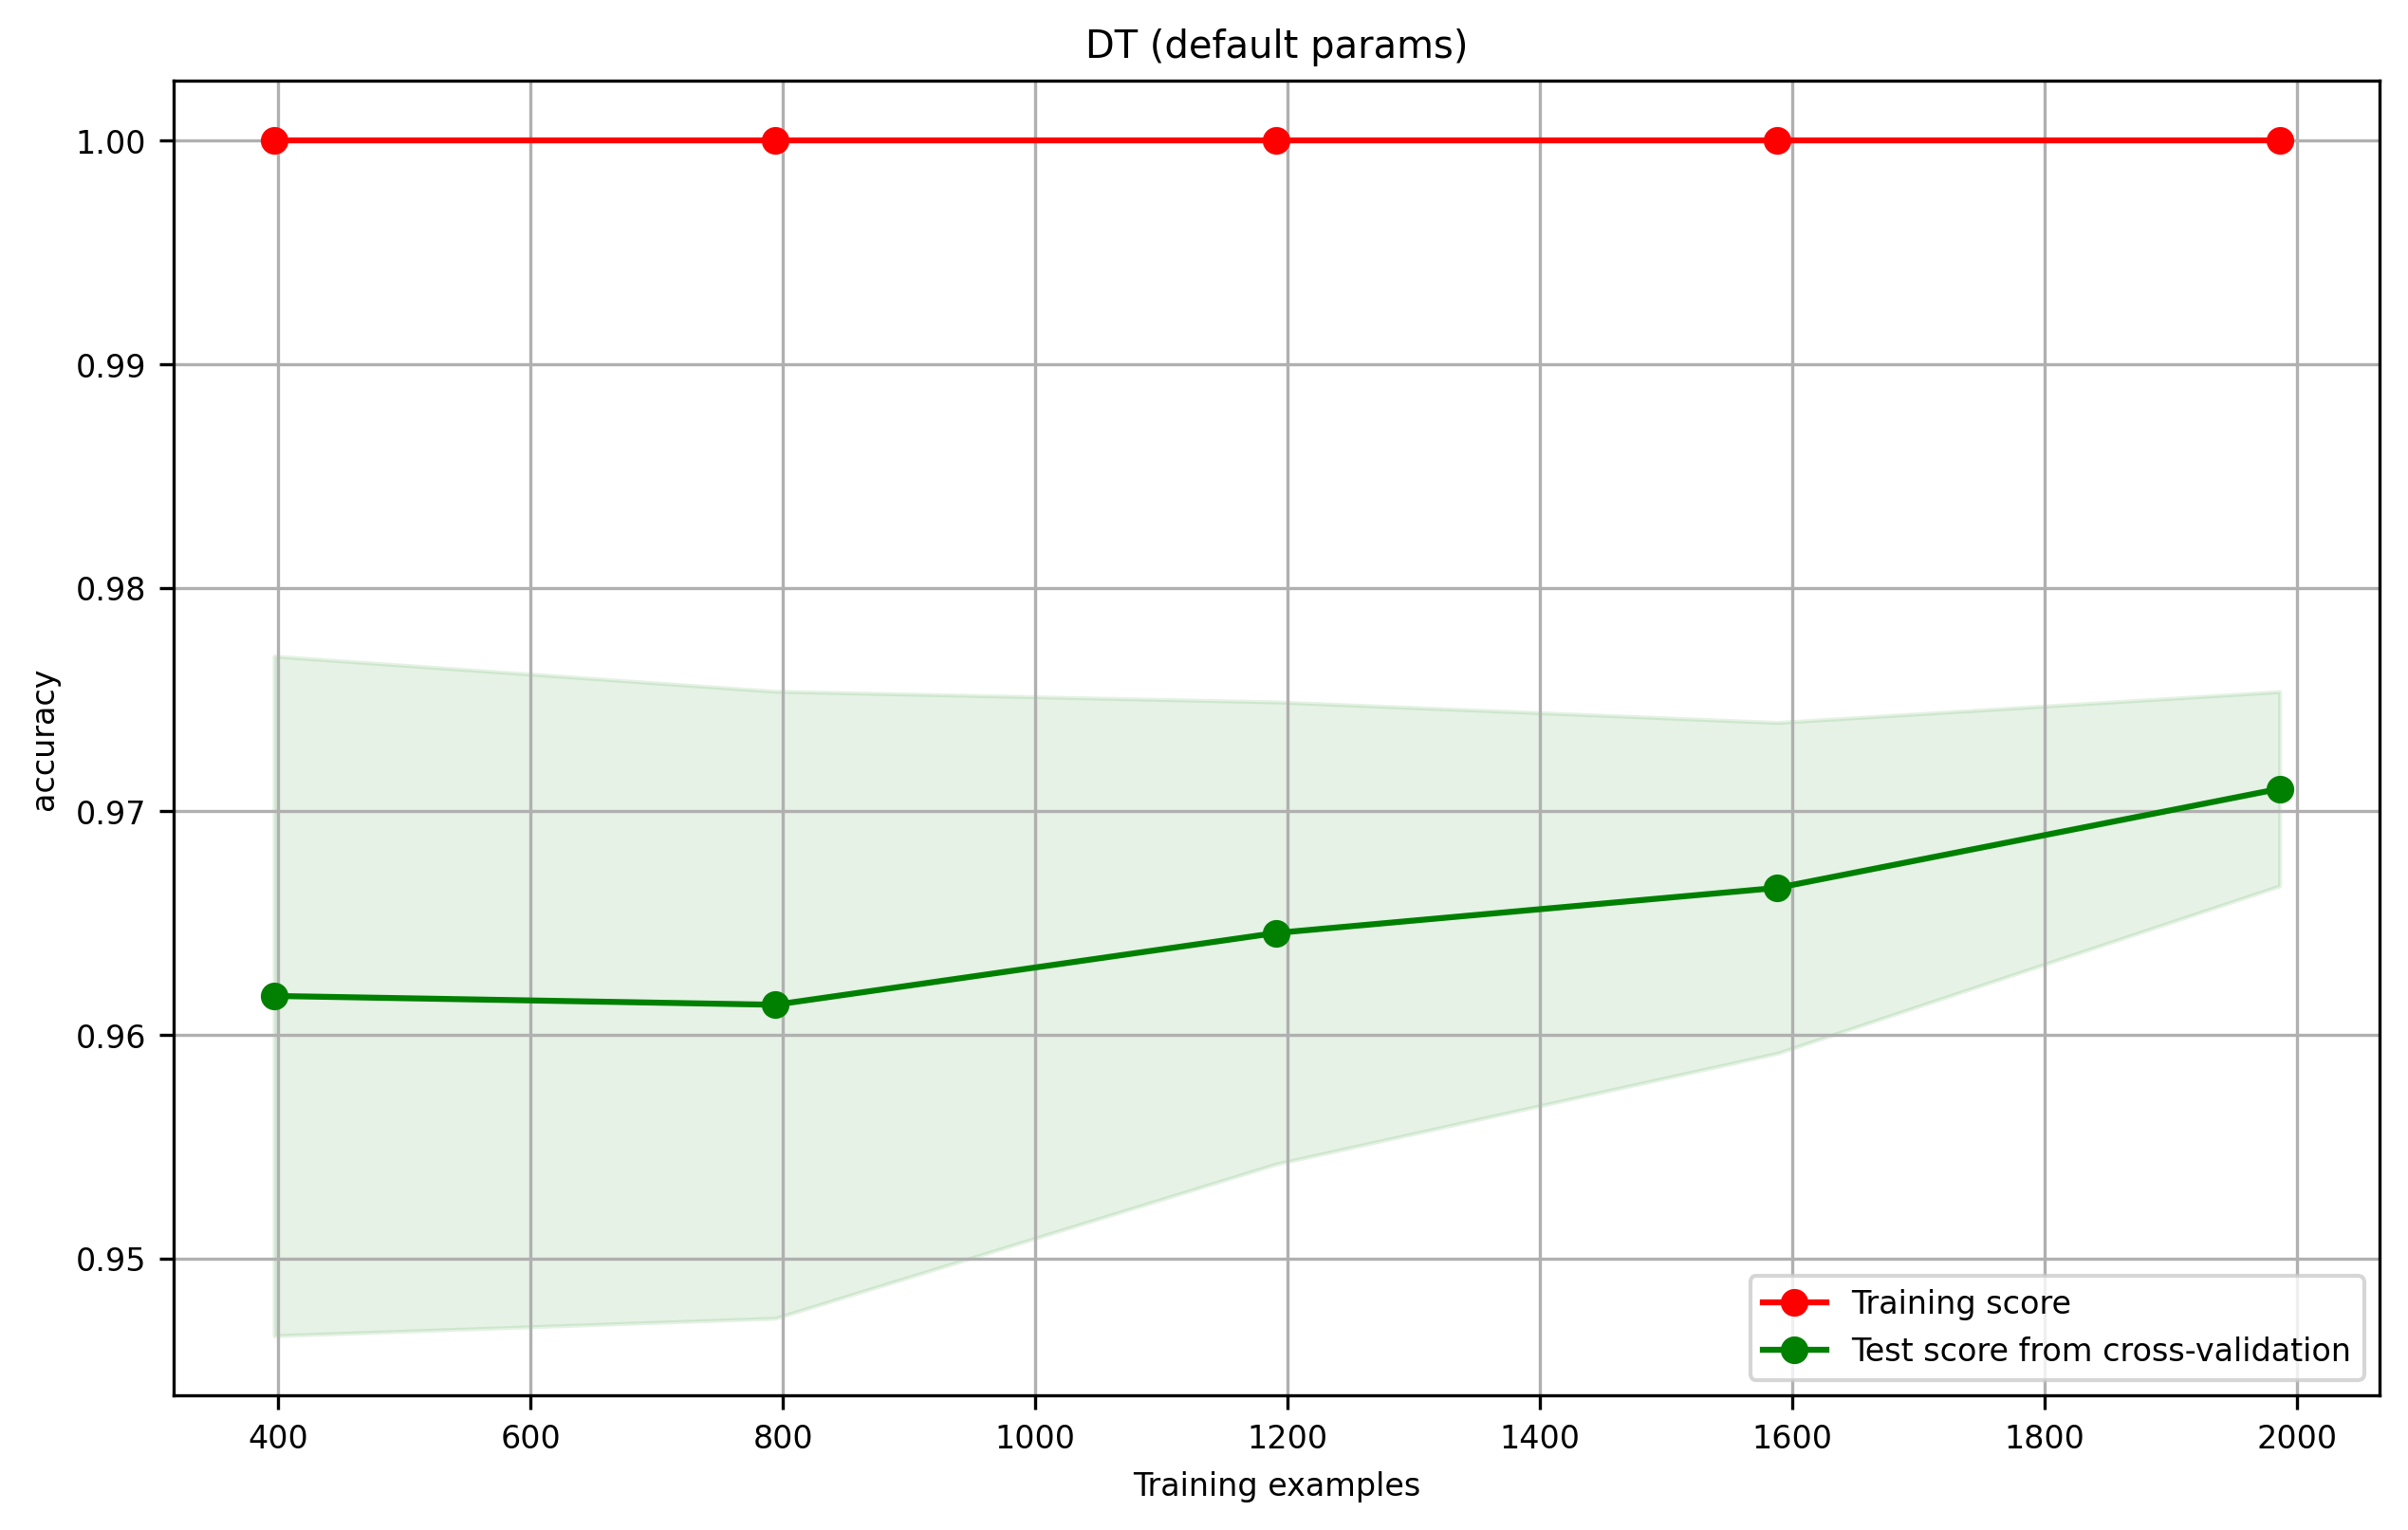

In [46]:
plot_learning_curve(model, 'DT (default params)', X, y,  cv = cv3, scoring = 'accuracy');

### **Preguntas**

Responda brevemente:

1. ¿Existe una brecha entre la curva de entrenamiento y la de validación? ¿Qué sugiere eso?
2. ¿El rendimiento de validación mejora al agregar más ejemplos?
3. ¿Hablaría aquí de alto sesgo, alta varianza o sobreajuste moderado? Justifique.
4. Escriba una conclusión general sobre el comportamiento del árbol base a partir de estas curvas.

1.  Sí, se observa una brecha significativa entre la curva de entrenamiento (que está muy alta, cercana a 1.0) y la curva de validación (que es notablemente más baja). Esto sugiere que el modelo está aprendiendo los datos de entrenamiento demasiado bien, incluso el ruido, y no está generalizando de manera óptima a los datos no vistos.

2.  La curva de validación tiende a estabilizarse rápidamente y no muestra una mejora drástica a medida que se añaden más ejemplos de entrenamiento. La brecha con la curva de entrenamiento no se cierra significativamente con más datos, lo que indica que el problema no es principalmente la falta de datos, sino la complejidad inherente del modelo.

3. Hablaría de alta varianza y sobreajuste. El modelo tiene una alta varianza porque es demasiado flexible y complejo, lo que le permite capturar el ruido de los datos de entrenamiento. El *score* de entrenamiento casi perfecto (1.0) y un *score* de prueba inferior, aunque bueno, confirman que el modelo se ha memorizado los datos de entrenamiento pero le cuesta generalizar. No es un sesgo alto, ya que el modelo se ajusta perfectamente a los datos de entrenamiento.

4.  El árbol de decisión base, al no tener restricciones en su profundidad, exhibe un comportamiento de sobreajuste. Aunque es excelente en la clasificación de los datos con los que fue entrenado, su complejidad limita su capacidad para generalizar con la misma eficacia a datos nuevos y desconocidos. Para mejorar su rendimiento predictivo en la práctica, sería necesario aplicar técnicas de regularización o simplificación del modelo.

### Desafío: ¿un árbol más simple generaliza mejor?

Entrene ahora un segundo árbol, más restringido que el árbol base. Por ejemplo, puede probar con:

- `max_depth=3`, o
- `min_samples_leaf=10`

Luego compare su rendimiento con el árbol base usando:

- accuracy
- precision
- recall
- F1-score



In [47]:
# Entrenar un árbol de decisión más restringido con max_depth=3
model_tree_restricted = DecisionTreeClassifier(max_depth=3, random_state=42)

# Realizar validación cruzada para el modelo restringido
scoring_metrics = ['accuracy', 'precision', 'recall', 'f1']
scores_restricted = cross_validate(model_tree_restricted, X, y, cv=cv3, scoring=scoring_metrics, return_train_score=True)

print("Métricas para el árbol restringido (max_depth=3):")
for metric_name in scoring_metrics:
    test_scores_mean = scores_restricted[f'test_{metric_name}'].mean()
    test_scores_std = scores_restricted[f'test_{metric_name}'].std()
    print(f"  {metric_name.capitalize()}: {test_scores_mean:.3f} (+/- {test_scores_std:.3f})")

Métricas para el árbol restringido (max_depth=3):
  Accuracy: 0.977 (+/- 0.008)
  Precision: 0.925 (+/- 0.023)
  Recall: 0.961 (+/- 0.024)
  F1: 0.942 (+/- 0.019)


In [48]:
# Recalcular métricas para el árbol base para una comparación directa
scoring_metrics = ['accuracy', 'precision', 'recall', 'f1']
scores_base = cross_validate(model_tree, X, y, cv=cv3, scoring=scoring_metrics, return_train_score=True)

print("\nMétricas para el árbol base (sin restricciones):")
for metric_name in scoring_metrics:
    test_scores_mean = scores_base[f'test_{metric_name}'].mean()
    test_scores_std = scores_base[f'test_{metric_name}'].std()
    print(f"  {metric_name.capitalize()}: {test_scores_mean:.3f} (+/- {test_scores_std:.3f})")


Métricas para el árbol base (sin restricciones):
  Accuracy: 0.971 (+/- 0.004)
  Precision: 0.920 (+/- 0.012)
  Recall: 0.932 (+/- 0.014)
  F1: 0.926 (+/- 0.011)


Ahora que tenemos los resultados, podemos responder a las preguntas propuestas.

### Preguntas

A partir de los resultados obtenidos con validación cruzada:

1. ¿Qué ocurrió con el rendimiento al restringir la complejidad del árbol?
2. ¿El árbol más simple empeoró o mejoró la generalización?
3. ¿Qué sugieren estos resultados sobre el árbol base?
4. En este problema, ¿parece conveniente usar el árbol sin restricciones?
5. ¿Qué métrica le parece más importante para decidir entre ambos modelos?

1.  El rendimiento general del modelo mejoró en todas las métricas de evaluación (Accuracy, Precision, Recall) en el conjunto de validación.
2.  El árbol más simple mejoró la generalización.

3.  Estos resultados sugieren que el árbol base (sin restricciones) estaba sufriendo de sobreajuste.

4.  No, no parece conveniente usar el árbol sin restricciones.

5.  Dada la naturaleza del problema (clasificación de una clase minoritaria como las RR Lyrae) y los objetivos científicos planteados anteriormente:
    *   Si el objetivo principal es encontrar la *mayor cantidad posible* de RR Lyrae, la métrica más importante sería el Recall, ya que mide la capacidad del modelo para identificar todos los positivos reales y minimizar los falsos negativos. En este caso, el árbol restringido tuvo un `Recall` superior (0.961 vs 0.932).
    *   Si el objetivo es construir una *muestra final más limpia* con la menor cantidad de falsos positivos, la métrica más importante sería la Precision. El árbol restringido también mostró una `Precision` ligeramente mejor (0.925 vs 0.920).
    

### Comparación con el árbol simple

Aquí están las métricas del árbol simple (`max_depth=3`) para facilitar la comparación:

*   **Accuracy (Árbol restringido):** 0.977 (+/- 0.008)
*   **Precision (Árbol restringido):** 0.925 (+/- 0.023)
*   **Recall (Árbol restringido):** 0.961 (+/- 0.024)
*   **F1-score (Árbol restringido):** 0.942 (+/- 0.019)

## Desafío: comparar con kNN

Hasta ahora trabajamos con árboles de decisión. Ahora comparemos ese enfoque con un clasificador distinto: **k-Nearest Neighbors (kNN)**.

Entrene un modelo kNN y compárelo con el árbol simple usando validación cruzada estratificada. Recuerde que kNN está basado en distancias, por lo que antes de entrenarlo debe escalar las variables.

### Instrucciones

1. Entrene un modelo kNN con `k=5`.
2. Use un `StandardScaler` antes del clasificador.
3. Evalúe el modelo con validación cruzada estratificada usando:
   - accuracy
   - precision
   - recall
   - F1-score
4. Compare sus resultados con los del árbol simple.
5. Luego explore distintos valores de `k` y vea cómo cambian las métricas.

### Preguntas

1. ¿Cómo se compara el rendimiento de kNN con el del árbol simple?
2. ¿Qué ocurre cuando `k` es muy pequeño?
3. ¿Qué ocurre cuando `k` es muy grande?
4. ¿Qué valor de `k` parece dar el mejor equilibrio entre precision y recall?
5. ¿Qué ventaja podría tener kNN si la frontera entre clases no es rectangular?

In [49]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# 1. Entrenar un modelo kNN con k=5
# 2. Usar un StandardScaler antes del clasificador
k_value = 5
knn_model = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier(n_neighbors=k_value))
])

# 3. Evaluar el modelo con validación cruzada estratificada
scoring_metrics = ['accuracy', 'precision', 'recall', 'f1']
scores_knn = cross_validate(knn_model, X, y, cv=cv3, scoring=scoring_metrics, return_train_score=True)

print(f"Métricas para el modelo kNN (k={k_value}):")
for metric_name in scoring_metrics:
    test_scores_mean = scores_knn[f'test_{metric_name}'].mean()
    test_scores_std = scores_knn[f'test_{metric_name}'].std()
    print(f"  {metric_name.capitalize()}: {test_scores_mean:.3f} (+/- {test_scores_std:.3f})")

Métricas para el modelo kNN (k=5):
  Accuracy: 0.978 (+/- 0.006)
  Precision: 0.922 (+/- 0.021)
  Recall: 0.969 (+/- 0.011)
  F1: 0.945 (+/- 0.015)


In [50]:
# 5. Explorar distintos valores de k y ver cómo cambian las métricas
k_values_to_test = [1, 3, 5, 7, 10, 15, 20]
results_k_knn = []

print("\nExplorando diferentes valores de k para kNN:")
for k in k_values_to_test:
    knn_model_loop = Pipeline([
        ('scaler', StandardScaler()),
        ('knn', KNeighborsClassifier(n_neighbors=k))
    ])
    scores_k_current = cross_validate(knn_model_loop, X, y, cv=cv3, scoring=scoring_metrics, return_train_score=True)

    results_k_knn.append({
        'k': k,
        'accuracy': scores_k_current['test_accuracy'].mean(),
        'precision': scores_k_current['test_precision'].mean(),
        'recall': scores_k_current['test_recall'].mean(),
        'f1': scores_k_current['test_f1'].mean()
    })
    print(f"  k={k}: Acc={results_k_knn[-1]['accuracy']:.3f}, Prec={results_k_knn[-1]['precision']:.3f}, Rec={results_k_knn[-1]['recall']:.3f}, F1={results_k_knn[-1]['f1']:.3f}")

results_df = pd.DataFrame(results_k_knn)
print("\nResumen de resultados para diferentes valores de k:")
print(results_df)



Explorando diferentes valores de k para kNN:
  k=1: Acc=0.968, Prec=0.914, Rec=0.923, F1=0.919
  k=3: Acc=0.977, Prec=0.923, Rec=0.961, F1=0.941
  k=5: Acc=0.978, Prec=0.922, Rec=0.969, F1=0.945
  k=7: Acc=0.978, Prec=0.918, Rec=0.975, F1=0.946
  k=10: Acc=0.979, Prec=0.919, Rec=0.977, F1=0.947
  k=15: Acc=0.974, Prec=0.900, Rec=0.975, F1=0.936
  k=20: Acc=0.973, Prec=0.898, Rec=0.973, F1=0.934

Resumen de resultados para diferentes valores de k:
    k  accuracy  precision    recall        f1
0   1  0.968183   0.914128  0.923411  0.918686
1   3  0.976640   0.923070  0.960653  0.941376
2   5  0.977848   0.921513  0.968943  0.944569
3   7  0.978250   0.918473  0.975129  0.945853
4  10  0.978653   0.918933  0.977212  0.946930
5  15  0.973818   0.899939  0.975129  0.935671
6  20  0.973013   0.897799  0.973067  0.933691


## Cierre

En esta actividad vimos que evaluar un clasificador no consiste solo en obtener un score alto, sino en interpretar qué está midiendo cada métrica y cómo se construyen los conjuntos de validación. En este problema, el uso de validación cruzada estratificada fue importante para obtener una evaluación más estable y representativa.

También observamos que un modelo más complejo no siempre generaliza mejor. Aunque el árbol base ajustaba perfectamente los datos de entrenamiento, un árbol más simple logró mejores resultados en validación cruzada, lo que sugiere que reducir la complejidad ayudó a disminuir el sobreajuste.